## **MADIS Precipitation Gauge Observations**

### **Imports**

In [106]:

import numpy as np, random, os, matplotlib.pyplot as plt
import pandas as pd, geopandas as gpd
from pathlib import Path
from datetime import datetime, timedelta
import gzip
import shutil
from tqdm import tqdm
import requests
import time
import re

import xarray as xr

pd.set_option('display.max_columns', None)


### **Utils**

In [107]:

def parse_madis_response(text, variables):
    match = re.search(r"<pre>(.*?)</pre>", text, re.IGNORECASE | re.DOTALL)
    if not match:
        return pd.DataFrame()  # no <pre> block at all this hour - skip cleanly, don't guess

    body = match.group(1).strip()
    if not body or "No matching data found" in body:
        return pd.DataFrame()

    base_cols = ["station_id", "date", "time", "provider", "subprovider"]
    var_cols = []
    for v in variables:
        var_cols += [f"{v}_value", f"{v}_qcd", f"{v}_qca", f"{v}_qcr"]
    all_cols = base_cols + var_cols

    rows = []
    for line in body.splitlines():
        line = line.strip()
        if not line:
            continue
        fields = [f.strip() for f in line.split(",")]
        fields = fields[:len(all_cols)]
        if len(fields) == len(all_cols):
            rows.append(fields)

    return pd.DataFrame(rows, columns=all_cols)


def combine_precip(row):
    if row["PCP1H_value"] != MISSING:
        return row["PCP1H_value"], row["PCP1H_qcd"]
    elif row["PCP1HA_value"] != MISSING:
        return row["PCP1HA_value"], row["PCP1HA_qcd"]
    else:
        return np.nan, None


def inspect_station_hour(df, station_id, nominal_time, radius_deg=1.0):
    """Temporal + spatial context for one suspect station-hour."""
    temporal = df[df["station_id"] == station_id].sort_values("nominal_time")
    print(f"--- {station_id}: full day ---")
    display(temporal[["nominal_time", "provider", "precip_1h_mm", "precip_1h_qcd"]])

    target_row = df[(df["station_id"] == station_id) & (df["nominal_time"] == nominal_time)].iloc[0]
    same_hour = df[df["nominal_time"] == nominal_time].copy()
    same_hour["dist_deg"] = same_hour.geometry.distance(target_row.geometry)
    nearby = same_hour[same_hour["dist_deg"] <= radius_deg].sort_values("dist_deg")

    print(f"\n--- Stations within {radius_deg}° of {station_id} at {nominal_time} ---")
    display(nearby[["station_id", "provider", "precip_1h_mm", "precip_1h_qcd", "dist_deg"]].head(15))


def minutes_from_hour(time_str):
    try:
        hh, mm = time_str.split(":")
        mm = int(mm)
        return min(mm, 60 - mm)   # '07:00'->0, '19:30'->30, '20:56'->4
    except Exception:
        return 999

def flag_ties(g):
    g = g.copy()
    g["tie_break_arbitrary"] = False
    if len(g) >= 2 and (g[rank_cols].iloc[:2].nunique() == 1).all():
        g.iloc[0, g.columns.get_loc("tie_break_arbitrary")] = True
    return g



### **Paths**

In [108]:

root_path = Path.cwd()
madis_csv_path = root_path / 'data/samples'

madis_csv_path.mkdir(parents=True, exist_ok=True)

shape_file_path = Path("/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/shapefiles/river_forecast_centers/rf05mr24/rf05mr24.shp")

print(madis_csv_path.exists(), shape_file_path.exists())


True True


The **Meteorological Assimilation Data Ingest System (MADIS)** is a NOAA observational data system that collects, standardizes, and quality-controls meteorological observations from a large number of surface observing networks. These observations include variables such as temperature, wind, pressure, and precipitation, together with station metadata and quality-control information.

Unlike MRMS `RadarOnly_QPE_01H`, which provides a **spatially continuous radar-derived precipitation estimate**, MADIS provides **direct point-based observations from surface stations and rain gauges**. Therefore, MADIS precipitation measurements can provide independent observational information about how much rainfall was actually measured at specific locations.

In this project, MADIS gauge observations will be investigated as a source of precipitation information that can help identify and correct errors in MRMS RadarOnly QPE. Conceptually, if RadarOnly QPE estimates R = 6mm while a nearby reliable gauge measures G = 9mm, the gauge provides evidence that the radar estimate may be underestimating precipitation at that location.

The initial reliability-aware framework can therefore be viewed as:

$$\text{RadarOnly QPE} + \text{RAQI} + \text{Gauge Information} \rightarrow \text{Improved QPE}$$

where **RadarOnly QPE** provides the baseline precipitation estimate, **RAQI** provides information about the reliability of the radar observation, and **MADIS gauges** provide direct surface precipitation measurements that can guide the correction.

### **Relevant MADIS Dataset**

The most relevant source is the **MADIS Meteorological Surface / Integrated Mesonet dataset**, which combines observations from many surface networks and includes precipitation measurements from stations such as HADS/AFWS and other mesonets.

### **Precipitation Variables**

MADIS provides precipitation over several accumulation periods, including:

| Variable | Meaning |
|---|---|
| `PCP5M` | 5-minute accumulated precipitation |
| `PCP15M` | 15-minute accumulated precipitation |
| `PCP1H` | 1-hour accumulated precipitation |
| `PCP1HA` | 1-hour accumulated precipitation, ASOS start-of-hour convention |
| `PCP3H` | 3-hour accumulated precipitation |
| `PCP6H` | 6-hour accumulated precipitation |
| `PCP12H` | 12-hour accumulated precipitation |
| `PCP24H` | 24-hour accumulated precipitation |
| `PCPLM` | Accumulation since local midnight |
| `PCPUTCM` | Accumulation since UTC midnight |
| `PCPTOTL` | Total precipitation over a provider-dependent period |

For this project, we use **both `PCP1H` and `PCP1HA`** to build a single hourly precipitation value. Most networks (MesoWest, HADS, RAWS, APRSWXNET, CoAgMet) report under `PCP1H`. ASOS-HFM (one-minute ASOS) stations only report under `PCP1HA` - using `PCP1H` alone would silently exclude them. We also learned that `PCP1HA`'s accumulation window doesn't always align to the clock hour the way `PCP1H` does, which we account for later during data exploration and duplicate resolution.

### **Temporal Resolution and Spatial Coverage**

MADIS does not have one fixed reporting frequency. Reporting intervals depend on the contributing network and may range from a few minutes to daily observations.

It is important to distinguish:

$$\text{Reporting Frequency} \neq \text{Accumulation Period}$$

For example, a station may report every 5 minutes while still providing a rolling 1-hour precipitation accumulation.

As for spatial coverage, MADIS combines many observing networks, so station density and precipitation availability vary geographically. Actual station counts and coverage for our study region are worked out in the Data Exploration section below, using our first sample day.

### **Quality Control**

MADIS provides quality-control information for many observations, including:

- `QCD` - overall quality-control descriptor
- `QCA` - QC checks applied
- `QCR` - results of individual QC checks

Precipitation observations generally receive relatively basic validity/range checks, so QC-passed observations will still be treated as measurements with possible uncertainty rather than ground truth. Our exploration later confirms this in practice - precipitation QC flags in our study region rarely go beyond the basic pass level.

### **Data Access**

We pull data through MADIS's public web-based query interface rather than downloading and parsing raw NetCDF files directly. This interface lets us request specific variables (`PCP1H`, `PCP1HA`, station coordinates, etc.) for a given time and geographic area, with quality-control information and a consistent missing-value convention (`-99999`) already applied - avoiding the need to interpret provider-specific raw accumulation conventions ourselves. Details of this approach are in the Data Download section below.

### **Data Download**

Our first instinct was to download raw **Integrated Mesonet NetCDF files** directly from MADIS's archive and parse `PCP1H`/`precipAccum` ourselves. We moved away from this for a concrete reason: different provider networks store precipitation under different conventions (1-hour accumulation, 24-hour accumulation reported hourly, accumulation since local midnight, etc.), and reconstructing those conventions correctly ourselves would mean re-implementing logic MADIS already handles internally.

Instead, we use **MADIS's public web-based query interface** (`madisXmlPublicDir`), which lets us request an already-standardized variable (like `PCP1H`) for a specific time, geographic area, and set of providers, with a consistent missing-value convention applied server-side. This is a plain HTTP GET request - we found the exact parameter structure by manually submitting the form once in a browser and capturing the resulting request.

**How a request is built:**

A request is one HTTP GET to:
```text
https://madis-data.ncep.noaa.gov/madisPublic/cgi-bin/madisXmlPublicDir
```
with parameters covering: the nominal time window (`time`, `minbck`, `minfwd`), the geographic bounding box (`latll`, `lonll`, `latur`, `lonur`), which variables to return (`nvars`, repeated per variable), the QC filter level (`qcsel` - we use `0`, meaning *keep everything*; see Quality Control above), the output format (`xml=4`, CSV with full QC info), and the missing-value convention (`csvmiss=0`, meaning missing values come back as `-99999`).

This interface only answers for **one nominal time at a time** (a fixed window around a single hour). To cover a full day, we loop over all 24 hourly times and issue one request per hour, saving each response into a dictionary keyed by nominal time.

**Variables requested:** `PCP1H`, `PCP1HA` (both — see Precipitation Variables above for why), plus `LAT`/`LON` so we can later filter stations to our exact RFC boundary using its shapefile, rather than just the bounding box the query itself accepts.

**One parsing detail worth flagging:** MADIS wraps its CSV output inside a small HTML shell (`<pre>...</pre>`), so responses need that block extracted before being read as tabular data.

Once downloaded, we inspect:
* the parsed table's structure (station, time, provider, variable values, QC fields),
* precipitation units and accumulation periods (confirmed as meters, matching MRMS after unit conversion),
* missing-value handling (`-99999`, as requested),
* quality-control descriptors,
* number and spatial distribution of reporting stations within our RFC boundary,
* and consistency across the 24 hourly requests for a single day.

Details of how we arrived at this specific request structure - including the alternative "MADIS API" (a separate, local Fortran-based tool that we evaluated and decided against) - are preserved in our working notes, since that reasoning may be worth revisiting if this web interface ever changes.

#### **Shape File**

In [6]:

# lets read the shape file and we will work on Colorado basin for this session
shape_data = gpd.read_file(shape_file_path)
colrd_data = shape_data[shape_data['RFC_NAME']=='Colorado Basin'].reset_index(drop=True)

# we will be using madis API to directly fetch the data and it only need  Lats and Longs/BBOX, 
# does not need the whole shapefile - so lets get those
lon_min, lat_min, lon_max, lat_max = colrd_data.total_bounds
print(f"Colorado Basin bounding box: lat [{lat_min:.3f}, {lat_max:.3f}], lon [{lon_min:.3f}, {lon_max:.3f}]")


Colorado Basin bounding box: lat [30.945, 43.458], lon [-115.734, -105.625]


#### **Data Download**

In [7]:

# we will download the data from a random date. lets get that date
start_date = datetime(2020, 10, 16)
end_date = datetime.today() - timedelta(days=1)

# get a random date
random_days = random.randint(0, (end_date - start_date).days)
selected_date = start_date + timedelta(days=random_days)
random_date = selected_date.strftime("%Y%m%d")
print("Selected random date:", random_date)

# lets define the hours, we will be downloading data for the whole day so we can confirm the temporal resolution etc
hours = [f"{h:02d}00" for h in range(24)]
base_url = "https://madis-data.ncep.noaa.gov/madisPublic/cgi-bin/madisXmlPublicDir"

# some RFC return only PCP1H while other return PCP1HA - same variables with different names
variables = ["PCP1H", "PCP1HA", "LAT", "LON"]  # order matters, later when we will parse we will use this order

# now lets define the dictionary to ask for the data - see this webpage https://madis-data.ncep.noaa.gov/public/sfcdump.html
# we can fill out above page and then se the url it returns, it will have different variables, below are those variables
params_template = {
    "rdr": "",
    "minbck": -59,
    "minfwd": 0,
    "recwin": 3,
    "timefilter": 0,
    "dfltrsel": 1,
    "state": "AK",         # unused leftover field, since we will be using Lats/Longs
    "latll": lat_min,
    "lonll": lon_min,
    "latur": lat_max,
    "lonur": lon_max,
    "stanam": "",
    "stasel": 0,
    "pvdrsel": 0,
    "varsel": 1,
    "qctype": 0,
    "qcsel": 0,             # keep everything, QC stays as a column 
    "xml": 4,               # CSV with full QC
    "csvmiss": 0,           # -99999 for missing
    }


# now we will download the data for the whole day, making 24 requests, one for each hour and for each hour we will 
# fill the hours from hours list and then create the url using above base url and params_template

raw_texts = {} # since we are not filtering any, we are getting all the data - later we will see how to use QC for filtering/modeling

# loop through each hour and fecth the data store in the dictionary
for hour in tqdm(hours, desc=f"Downloading {random_date}"):

    # get the time and add in the params_template
    nominal_time = f"{random_date}_{hour}"
    params = params_template.copy()
    params["time"] = nominal_time

    url = f"{base_url}?" + "&".join(f"{k}={v}" for k, v in params.items())
    url += "".join(f"&nvars={v}" for v in variables) # clicking on this URL will return the data in the form of HTML 

    response = requests.get(url, timeout=60, headers={"User-Agent": "research-script/1.0"})

    # add in the dictionary
    raw_texts[nominal_time] = response.text

    # set the path
    out_path = madis_csv_path / nominal_time.split("_")[0]
    out_path.mkdir(parents=True, exist_ok=True)
    out_path = out_path / f"madis_{nominal_time}.txt"
    
    with open(out_path, "w") as f:
        f.write(response.text)

    time.sleep(1)  # polite pause between requests

print(f"\nDownloaded {len(raw_texts)} hourly files to {madis_csv_path}")


Selected random date: 20250424



Downloaded 24 hourly files to /home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/madis_gage_observations/data/samples


### **Data Exploration**

Now that we have MADIS gauge data downloaded for one sample day and one RFC region, its time to actually look at it before we build anything on top of it.

The point of this section is simple: **get comfortable with what we actually have, before trusting it.** We downloaded raw hourly text files, parsed them into a table, combined `PCP1H`/`PCP1HA` into one usable precip column, and filtered stations down to the ones truly inside the basin polygon. But "the code ran without errors" isn't the same as "the data makes sense."

Here we will look at things:
- How many stations do we actually have inside the basin, and from which providers?
- How much of the data is missing, and does that missingness look random or does it cluster in certain areas/hours?
- What does the range of hourly precipitation values look like, any negative numbers, any suspiciously huge numbers?
- What do the QC flags tell us, is most of our data "coarse pass" only, or do we have a decent amount of higher-confidence (`S`/`V`) observations?
- Are stations spread out evenly across the basin, or clumped in a few spots (which matters a lot for the gauge-sparse regions this whole project cares about)?


In [109]:

# lets read all 24 files and parse them - we will read the data from the dictionary
MISSING = -99999.0

all_hours_df = []
empty_hours = []

for nominal_time, text in raw_texts.items():
    df = parse_madis_response(text, variables)
    if df.empty:
        empty_hours.append(nominal_time)
    else:
        df["nominal_time"] = nominal_time
        all_hours_df.append(df)

print(f"Empty/failed hours: {empty_hours if empty_hours else 'none'}")

day_df = pd.concat(all_hours_df, ignore_index=True)
print(f"Total Raw Rows - Before Passing QC Checks and Without Spatial Filtering: {len(day_df)}")

# we need data only for a single colorado basin - lets filter that one
# first filter out any rows which does not have Lats/Longs - should not happen but still possible
valid_latlon = (day_df["LAT_value"] != MISSING) & (day_df["LON_value"] != MISSING)
day_df_geo = day_df[valid_latlon].copy()
stations_gdf = gpd.GeoDataFrame(day_df_geo, 
                    geometry=gpd.points_from_xy(day_df_geo["LON_value"], day_df_geo["LAT_value"]),
                    crs=colrd_data.crs)

basin_geom = colrd_data.geometry.iloc[0]
in_basin_df = stations_gdf[stations_gdf.within(basin_geom)].reset_index(drop=True)

print(f"Box rows with valid lat/lon: {len(day_df_geo)}")
print(f"Rows actually inside Colorado Basin polygon: {len(in_basin_df)}")
print(f"Unique stations inside basin: {in_basin_df['station_id'].nunique()}")
print(f"Providers present inside basin:\n{in_basin_df.groupby('provider')['station_id'].nunique()}")

print(f"Total Raw Rows - After Passing Spatial Filtering: {len(in_basin_df)}")


Empty/failed hours: none
Total Raw Rows - Before Passing QC Checks and Without Spatial Filtering: 102789
Box rows with valid lat/lon: 102789
Rows actually inside Colorado Basin polygon: 79557
Unique stations inside basin: 3509
Providers present inside basin:
provider
APRSWXNET      509
ASOS            42
ASOS-HFM        49
CAIC            35
CRN             10
CoAgMet         25
HADS           326
ITD             13
MAP              2
MesoWest      2269
NRCS             1
NonFedAWOS      26
OTHER-MTR       54
RAWS           278
Name: station_id, dtype: int64
Total Raw Rows - After Passing Spatial Filtering: 79557


So starting from the raw pull: all 24 hourly requests came back with data - no empty hours, good, nothing silently failed. Before any filtering we had 102,789 rows, and every single one of them had a valid lat/lon, so no rows got dropped at that check.

Once we filtered down to the actual Colorado Basin polygon (not just the bounding box we queried with), we lost about 23% of the rows - down to 79,557, covering 3,509 unique stations. That gap between box and actual basin is a nice confirmation that using the real shapefile mattered here, not just a formality - a meaningful chunk of what the box returned was genuinely outside the basin.

MesoWest is clearly the dominant network by station count - 2,269 stations- with HADS, APRSWXNET, and RAWS making up most of the rest. The official ASOS/ASOS-HFM stations are a small slice by comparison - 42 and 49 respectively, we already know these two report through different variables (`PCP1H` vs `PCP1HA`) and behave differently around clock-hour alignment, and we deal with that later in the duplicates section.

This is still the raw, pre-dedup table - same station can (and does) show up more than once per hour if multiple providers report it, which is exactly what we untangle next.

In [152]:

basin_df = in_basin_df.copy()
# now lets check the data distribution - we will check the variable wise
value_cols = ["PCP1H_value", "PCP1HA_value", "LAT_value", "LON_value"]
for col in value_cols:
    basin_df[col] = pd.to_numeric(basin_df[col], errors="coerce")

print("Raw PCP1H_value distribution - BEFORE excluding missing:")
print(basin_df["PCP1H_value"].describe())
print("\nUnique low-end values - Checking if Sentinel is really -99999:")
print(sorted(basin_df["PCP1H_value"].unique())[:5])
print("=" * 50)

# now lets combine both variables into a single variable since both represents the same value
basin_df[["precip_1h_m", "precip_1h_qcd"]] = basin_df.apply( lambda r: pd.Series(combine_precip(r)), axis=1)
basin_df["precip_1h_mm"] = basin_df["precip_1h_m"] * 1000  # meters to mm - this matches MRMS units

print(f"Rows with a usable hourly precip value: {basin_df['precip_1h_mm'].notna().sum()} / {len(basin_df)}")
print(f"Missing rate: {basin_df['precip_1h_mm'].isna().mean():.1%}")
print("=" * 50)

# lets see if there are any duplicates too - these should not exist but lets see
dupes = basin_df.duplicated(subset=["station_id", "nominal_time"], keep=False)
print(f"Duplicate station+hour rows: {dupes.sum()}")
if dupes.sum() > 0:
    display(basin_df[dupes].sort_values(["station_id", "nominal_time"]).head(10))


Raw PCP1H_value distribution - BEFORE excluding missing:
count    79557.000000
mean    -67462.904932
std      46850.902651
min     -99999.000000
25%     -99999.000000
50%     -99999.000000
75%          0.000000
max          0.064770
Name: PCP1H_value, dtype: float64

Unique low-end values - Checking if Sentinel is really -99999:
[np.float64(-99999.0), np.float64(0.0), np.float64(0.000127), np.float64(0.000254), np.float64(0.0003)]
Rows with a usable hourly precip value: 27037 / 79557
Missing rate: 66.0%
Duplicate station+hour rows: 5341


,station_id,date,time,provider,subprovider,PCP1H_value,PCP1H_qcd,PCP1H_qca,PCP1H_qcr,PCP1HA_value,PCP1HA_qcd,PCP1HA_qca,PCP1HA_qcr,LAT_value,LAT_qcd,LAT_qca,LAT_qcr,LON_value,LON_qcd,LON_qca,LON_qcr,nominal_time,geometry,precip_1h_m,precip_1h_qcd,precip_1h_mm
2645,ADRA3,04/24/2025,00:00,MesoWest,CRN,0.0,Z,0,0,-99999.0,Z,0,0,31.590830,Z,0,0,-110.508614,Z,0,0,20250424_0000,POINT (-110.50861 31.59083),0.0,Z,0.0
2815,ADRA3,04/24/2025,00:00,HADS,,0.0,C,3,0,-99999.0,Z,0,0,31.590799,Z,0,0,-110.509003,Z,0,0,20250424_0000,POINT (-110.509 31.5908),0.0,C,0.0
3330,ADRA3,04/24/2025,00:00,CRN,,0.0,C,3,0,-99999.0,Z,0,0,31.590561,Z,0,0,-110.514442,Z,0,0,20250424_0000,POINT (-110.51444 31.59056),0.0,C,0.0
5981,ADRA3,04/24/2025,01:00,MesoWest,CRN,0.0,Z,0,0,-99999.0,Z,0,0,31.590830,Z,0,0,-110.508614,Z,0,0,20250424_0100,POINT (-110.50861 31.59083),0.0,Z,0.0
6153,ADRA3,04/24/2025,01:00,HADS,,0.0,C,3,0,-99999.0,Z,0,0,31.590799,Z,0,0,-110.509003,Z,0,0,20250424_0100,POINT (-110.509 31.5908),0.0,C,0.0
6669,ADRA3,04/24/2025,01:00,CRN,,0.0,C,3,0,-99999.0,Z,0,0,31.590561,Z,0,0,-110.514442,Z,0,0,20250424_0100,POINT (-110.51444 31.59056),0.0,C,0.0
9322,ADRA3,04/24/2025,02:00,MesoWest,CRN,0.0,Z,0,0,-99999.0,Z,0,0,31.590830,Z,0,0,-110.508614,Z,0,0,20250424_0200,POINT (-110.50861 31.59083),0.0,Z,0.0
9498,ADRA3,04/24/2025,02:00,HADS,,0.0,C,3,0,-99999.0,Z,0,0,31.590799,Z,0,0,-110.509003,Z,0,0,20250424_0200,POINT (-110.509 31.5908),0.0,C,0.0
10009,ADRA3,04/24/2025,02:00,CRN,,0.0,C,3,0,-99999.0,Z,0,0,31.590561,Z,0,0,-110.514442,Z,0,0,20250424_0200,POINT (-110.51444 31.59056),0.0,C,0.0
12635,ADRA3,04/24/2025,03:00,MesoWest,CRN,0.0,Z,0,0,-99999.0,Z,0,0,31.590830,Z,0,0,-110.508614,Z,0,0,20250424_0300,POINT (-110.50861 31.59083),0.0,Z,0.0


This cell does three things: converts the value columns to real numbers, combines `PCP1H`/`PCP1HA` into one usable `precip_1h_mm` column, and checks for duplicate station-hour rows.

Before excluding anything, the raw `PCP1H_value` column confirms `-99999` really is the sentinel MADIS is using for missing (not some other placeholder),  good, matches what we asked for with `csvmiss=0`. Combining `PCP1H` and `PCP1HA` and converting to mm gives us a missing rate right around two-thirds of all rows (66%, as we found earlier at this same stage), a first look at just how sparse this basin's gauge coverage really is on an hourly basis, well before we even get to spatial gaps.

The duplicate check is where it gets interesting, and the table above is a good example of *why* duplicates show up at all. `ADRA3` reports three times every hour: once via `MesoWest` (subprovider `CRN`), once via `HADS`, and once via `CRN` directly. Same physical gauge, three separate ingestion pipelines into MADIS, we can tell it is the same station because the lat/lon values are nearly identical (tens of meters apart, not truly different locations). This is not corrupted data, it is just MADIS re-broadcasting one instruments reading through multiple network feeds under the same station ID. We work through how to resolve this properly - and why a naive just drop duplicates approach would be a mistake, in the next section.

In [113]:
duplicates = basin_df[dupes].sort_values(["station_id", "nominal_time"]).copy()
duplicates.to_csv('./duplicates.csv', index=False)

Hourly precip (mm) inside Colorado Basin, 20250424:
count    27037.000000
mean         0.020506
std          1.607908
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        254.000000
Name: precip_1h_mm, dtype: float64


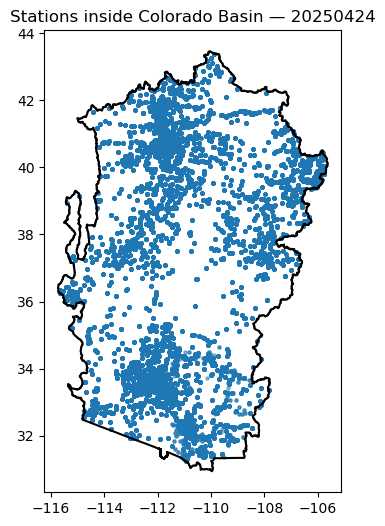

In [115]:

# getting stats - this time we will exclude the missing data indicator
valid_precip = basin_df["precip_1h_mm"].dropna()
print(f"Hourly precip (mm) inside Colorado Basin, {random_date}:")
print(valid_precip.describe())

# lets also have a quick visual sanity check: are the kept stations actually inside the polygon?
fig, ax = plt.subplots(figsize=(6, 6))
colrd_data.boundary.plot(ax=ax, color="black")
basin_df.plot(ax=ax, markersize=5, color="tab:blue", alpha=0.5)
ax.set_title(f"Stations inside Colorado Basin — {random_date}")
plt.show()


In [116]:

# weired: if you see the max value, it is 254, in one hour, that might be possible but i dont think so, lets further check it
outlier = basin_df.loc[basin_df["precip_1h_mm"].idxmax()]
print("Highest single-hour value in the dataset:")
display(outlier[["station_id", "provider", "nominal_time", "precip_1h_mm", "precip_1h_qcd"]])


Highest single-hour value in the dataset:


station_id                KBPI
provider              ASOS-HFM
nominal_time     20250424_0900
precip_1h_mm             254.0
precip_1h_qcd                C
Name: 33386, dtype: object

In [117]:

# Temporal check: does KBPI show a believable storm buildup, or an isolated spike
kbpi_day = basin_df[basin_df["station_id"] == "KBPI"].sort_values("nominal_time")
print("KBPI, full day:")
display(kbpi_day[["nominal_time", "provider", 'PCP1H_value', 'PCP1HA_value', "precip_1h_mm", "precip_1h_qcd"]])


KBPI, full day:


,nominal_time,provider,PCP1H_value,PCP1HA_value,precip_1h_mm,precip_1h_qcd
34,20250424_0000,ASOS,-99999.0000,-99999.000,NaN,NaN
3315,20250424_0000,ASOS-HFM,-99999.0000,0.000,0.0,C
3426,20250424_0100,ASOS,-99999.0000,-99999.000,NaN,NaN
6655,20250424_0100,ASOS-HFM,-99999.0000,0.000,0.0,C
6763,20250424_0200,ASOS,0.0000,-99999.000,0.0,C
9996,20250424_0200,ASOS-HFM,-99999.0000,0.000,0.0,C
10105,20250424_0300,ASOS,-99999.0000,-99999.000,NaN,NaN
13319,20250424_0300,ASOS-HFM,-99999.0000,0.000,0.0,C
13424,20250424_0400,ASOS,-99999.0000,-99999.000,NaN,NaN
16639,20250424_0400,ASOS-HFM,-99999.0000,0.000,0.0,C


Stations reporting at 09:00: 1143
Max value among them: 254.00 mm
How many exceeded 20mm: 1


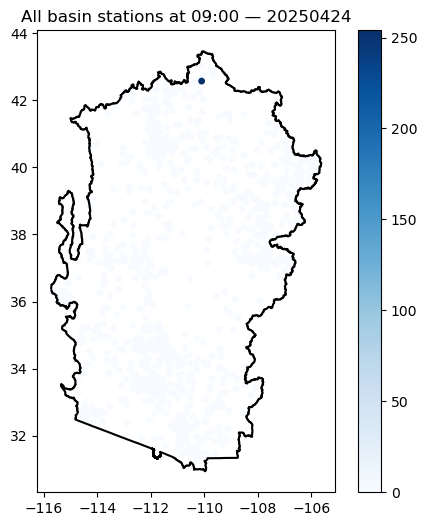

In [118]:

# Spatial check: did neighboring stations see anything like this at the same hour
same_hour = basin_df[basin_df["nominal_time"] == "20250424_0900"].copy()
same_hour_valid = same_hour.dropna(subset=["precip_1h_mm"])

print(f"Stations reporting at 09:00: {len(same_hour_valid)}")
print(f"Max value among them: {same_hour_valid['precip_1h_mm'].max():.2f} mm")
print(f"How many exceeded 20mm: {(same_hour_valid['precip_1h_mm'] > 20).sum()}")

# quick map: is KBPI sitting in a cluster of other heavy readings, or alone?
fig, ax = plt.subplots(figsize=(6, 6))
colrd_data.boundary.plot(ax=ax, color="black")
same_hour_valid.plot(ax=ax, column="precip_1h_mm", markersize=15, cmap="Blues", legend=True)
ax.set_title("All basin stations at 09:00 — 20250424")
plt.show()


In [119]:

# lets flag this one as outlier - this is way out of distribution and also if we check the other providers, 
# they reported 0 for the same gage
outlier_idx = basin_df["precip_1h_mm"].idxmax()
basin_df["outlier_suspect"] = False
basin_df.loc[outlier_idx, "outlier_suspect"] = True   # flag, don't silently drop

clean_precip = basin_df.loc[~basin_df["outlier_suspect"], "precip_1h_mm"].dropna()

print("Original max: 254.0 mm")
print(f"Max after excluding flagged outlier: {clean_precip.max():.2f} mm")
print(f"Second-highest 5 values:\n{clean_precip.sort_values(ascending=False).head(5)}")


Original max: 254.0 mm
Max after excluding flagged outlier: 64.77 mm
Second-highest 5 values:
25606    64.770
70092    29.464
69932     4.826
71124     4.318
75226     4.000
Name: precip_1h_mm, dtype: float64


In [120]:

# now if we see the next top 5, the first one looks suspicious to me - lets further investigate it. 
# lets see the temporal behavior and if we have other provider for the same gage, lets get those too
inspect_station_hour(basin_df, "NAGN5", "20250424_0700")


--- NAGN5: full day ---


,nominal_time,provider,precip_1h_mm,precip_1h_qcd
2251,20250424_0000,MesoWest,0.000,C
2304,20250424_0000,HADS,0.000,C
5597,20250424_0100,MesoWest,0.000,C
5654,20250424_0100,HADS,0.000,C
8941,20250424_0200,MesoWest,0.000,C
8992,20250424_0200,HADS,0.000,C
12252,20250424_0300,MesoWest,0.762,C
12308,20250424_0300,HADS,0.000,C
15582,20250424_0400,MesoWest,0.000,C
15635,20250424_0400,HADS,0.000,C



--- Stations within 1.0° of NAGN5 at 20250424_0700 ---


/tmp/ipykernel_114378/834177393.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  same_hour["dist_deg"] = same_hour.geometry.distance(target_row.geometry)


,station_id,provider,precip_1h_mm,precip_1h_qcd,dist_deg
25606,NAGN5,MesoWest,64.77,C,0.000000
25670,NAGN5,HADS,0.00,C,0.000444
24691,04NMC,MesoWest,NaN,NaN,0.511573
24692,12NMC,MesoWest,NaN,NaN,0.653747
25263,UCC36,MesoWest,NaN,NaN,0.656199
24694,NMC98,MesoWest,NaN,NaN,0.763284
23563,FASN5,MesoWest,NaN,NaN,0.767720
23408,KFMN,ASOS,NaN,NaN,0.785884
26629,KFMN,ASOS-HFM,0.00,C,0.785884
23826,D4879,APRSWXNET,0.00,C,0.798636


> We can see that we have two providers for the same gage, one is reporting 64 and other is reporting 0
additionally this stations rain amounts that day are tiny - 0.76mm, 0.51mm 
so 64.77mm is not just big in isolation, its around 85x bigger than anything else this same sensor reported all day.
Lets flag this one too

In [121]:

# setting it outlier
basin_df.loc[(basin_df["station_id"] == "NAGN5") & 
                (basin_df["nominal_time"] == "20250424_0700"), "outlier_suspect"] = True

# now what about 29 value - lets check it first 
inspect_station_hour(basin_df, "G5189", "20250424_2100")


--- G5189: full day ---


,nominal_time,provider,precip_1h_mm,precip_1h_qcd
394,20250424_0000,APRSWXNET,0.000,C
3733,20250424_0100,APRSWXNET,0.000,C
7068,20250424_0200,APRSWXNET,0.000,C
10410,20250424_0300,APRSWXNET,0.000,C
13720,20250424_0400,APRSWXNET,0.000,C
17059,20250424_0500,APRSWXNET,0.000,C
20560,20250424_0600,APRSWXNET,0.000,C
23751,20250424_0700,APRSWXNET,0.000,C
27086,20250424_0800,APRSWXNET,0.000,C
30478,20250424_0900,APRSWXNET,0.000,C



--- Stations within 1.0° of G5189 at 20250424_2100 ---


/tmp/ipykernel_114378/834177393.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  same_hour["dist_deg"] = same_hour.geometry.distance(target_row.geometry)


,station_id,provider,precip_1h_mm,precip_1h_qcd,dist_deg
70092,G5189,APRSWXNET,29.464,C,0.000000
71124,D4988,APRSWXNET,4.318,C,0.021355
71126,D5508,APRSWXNET,0.000,C,0.021520
70047,F5778,APRSWXNET,0.000,C,0.043867
70258,UT2SR,MesoWest,NaN,NaN,0.044370
71913,SLR13,MesoWest,NaN,NaN,0.047026
72316,UPGWX,MesoWest,0.000,C,0.047901
70117,E7419,APRSWXNET,0.000,C,0.049345
70015,E3770,APRSWXNET,0.000,C,0.056238
70049,F5941,APRSWXNET,0.000,C,0.056754


>This one does not seems to me out of distribution - if we check the spatial pattern, D4988 at 4.3mm sits 0.021 away around 2km
and F1924 at 3.0mm sits 0.062 away - i think this is believable decay gradient — 29 → 4 → 3 as you move a couple km outward 
exactly the footprint we would expect from a small, sharp convective cell centered almost directly on this gauge

In [125]:

# now, duplicates - we will align the values based on time alignment first, then QC
# plus the outlier work we just did
# lets first create a few helping columns
# defining QC ranks - we will use to identify which value has which rank/qc flag
qc_rank = {"V": 3, "S": 2, "C": 1, "Q": 0, "Z": 0, "X": -1}

basin_df["minutes_from_hour"] = basin_df["time"].apply(minutes_from_hour) 
basin_df["time_window_uncertain"] = (basin_df["provider"] == "ASOS-HFM")
basin_df["is_uncertain_pathway"] = basin_df["time_window_uncertain"].astype(int) # this is the flag we need, some of the providers such as
                                                                            # ASOS-HFM provide data from :45 to :44 so we 
                                                                        # want to keep track of those providers
basin_df["has_value"] = basin_df["precip_1h_mm"].notna().astype(int)
basin_df["qc_rank"] = basin_df["precip_1h_qcd"].map(qc_rank).fillna(-1) #map from the dictionary and if it does not have flag mark -1


# now comes the duplicate remover step - we will use the above information and prioritize values only those which are real.
# is it a ASOS-type, then how close it is to the clock hour and then QC rank - here we can see the QC rank is last since
# we dont want to delete any value just because it does not have good quality flag - we want to keep it and let the model
# figure out how to weight that value
basin_df_sorted = basin_df.sort_values(
                    by=["station_id", "nominal_time", "has_value", "is_uncertain_pathway", "minutes_from_hour", "qc_rank"],
                    ascending=[True, True, False, True, True, False]
                    ).reset_index(drop=True)

# nw lets define the main column which we will use to remove the duplicates
rank_cols = ["has_value", "is_uncertain_pathway", "minutes_from_hour", "qc_rank"]

grp = basin_df_sorted.groupby(["station_id", "nominal_time"], sort=False)
is_first_in_group = grp.cumcount() == 0                 # is this row the winner our sort picked?
next_row_vals = grp[rank_cols].shift(-1)                 # the row right after it, within the same group only
same_as_next = (basin_df_sorted[rank_cols] == next_row_vals).all(axis=1)  # did every rank column match exactly?

basin_df_sorted["tie_break_arbitrary"] = is_first_in_group & same_as_next


# now lets drop the duplicates - we will keep the first one
basin_df_dedup = basin_df_sorted.drop_duplicates(subset=["station_id", "nominal_time"], keep="first").reset_index(drop=True)

print(f"Before: {len(basin_df)} rows  →  After: {len(basin_df_dedup)} rows")
print(f"Tie-break-arbitrary rows: {basin_df_dedup['tie_break_arbitrary'].sum()}")

# sanity check: do KBPI and NAGN5 land in the tie-break group
check = basin_df_dedup[basin_df_dedup["station_id"] == "KBPI"]
display(check[["nominal_time", "provider", "precip_1h_mm", "tie_break_arbitrary", "outlier_suspect"]])

Before: 79557 rows  →  After: 76787 rows
Tie-break-arbitrary rows: 388


,nominal_time,provider,precip_1h_mm,tie_break_arbitrary,outlier_suspect
38573,20250424_0000,ASOS-HFM,0.0,False,False
38574,20250424_0100,ASOS-HFM,0.0,False,False
38575,20250424_0200,ASOS,0.0,False,False
38576,20250424_0300,ASOS-HFM,0.0,False,False
38577,20250424_0400,ASOS-HFM,0.0,False,False
38578,20250424_0500,ASOS,1.0,False,False
38579,20250424_0600,ASOS,0.0,False,False
38580,20250424_0700,ASOS-HFM,0.0,False,False
38581,20250424_0800,ASOS,0.0,False,False
38582,20250424_0900,ASOS,0.3,False,False


This is the step where duplicates actually get resolved, one row per station-hour, chosen using the priority we settled on earlier (real value first, avoid the uncertain ASOS-HFM pathway when there's a choice, prefer the reading closest to the clock hour, then fall back to QC rank).

The numbers: we go from 79,557 rows down to 76,787 after collapsing duplicates, so about 2,770 station-hours had more than one competing report that needed resolving. Of the final rows, 388 (under 1%) are marked `tie_break_arbitrary`, cases where two candidates were genuinely equal on every ranking column, so the winner was picked without a real basis. We are keeping those rows rather than dropping them, but the flag means we know exactly which ones to revisit later.

The KBPI check confirms the fix is doing what we intended - plain `ASOS` now consistently wins over `ASOS-HFM` whenever both report (e.g. 0.3mm at 09:00, not the 254mm outlier we caught earlier), and it is winning decisively rather than by tie-break luck.


In [126]:

# ok so we have around 76790 values, which means around 3K rows were removed during duplicates removal step
# now if we get the unique station ids and then multiply with the 24, we get above 80K rows for this date
# that means we have lot of missing rows, rows which were never returned from MADIS. lets confirm that.
# how many hourly reports does each station actually have, post-dedup
station_counts = basin_df_dedup.groupby("station_id")["nominal_time"].nunique()

print(f"Stations with all 24 hours: {(station_counts == 24).sum()} / {len(station_counts)}")
print(f"Stations with fewer than 24 hours: {(station_counts < 24).sum()}")
print("\nDistribution of hours-per-station:")
print(station_counts.describe())
print("\nA few examples with the fewest hours:")
print(station_counts.sort_values().head(20))


Stations with all 24 hours: 2514 / 3509
Stations with fewer than 24 hours: 995

Distribution of hours-per-station:
count    3509.000000
mean       21.882873
std         5.702798
min         1.000000
25%        23.000000
50%        24.000000
75%        24.000000
max        24.000000
Name: nominal_time, dtype: float64

A few examples with the fewest hours:
station_id
CRGA3    1
DAAA3    1
E1968    1
DCPA3    1
HGPA3    1
HCPA3    1
JE059    1
JE060    1
JE063    1
JE067    1
JE043    1
JE051    1
JE132    1
JE198    1
JE298    1
JE325    1
JE333    1
JE339    1
JE340    1
JE306    1
Name: nominal_time, dtype: int64


This confirms the hypothesis from the comment: with 3,509 stations × 24 possible hours, we'd expect 84,216 rows at full coverage, but we only have 76,787 - a gap of roughly 7,400 station-hours that MADIS simply never returned, separate entirely from the missing-*value* rows we've been tracking (where a row exists but the precip field itself is empty).

Most stations report reliably: 2,514 (about 72%) have full 24-hour coverage, and the median is a clean 24. But 995 stations (28%) are missing at least one hour, and the tail is long - the minimum is a single hour, and there's a cluster of stations (the `JE0xx`/`JE1xx`/`JE2xx`/`JE3xx` series in particular) that only ever show up once the entire day.

That `JE` cluster is worth a second look before we treat this number as final - a whole block of station IDs sharing a naming pattern and all reporting exactly once is a pattern, not scattered noise, and patterns like this are usually either a real shared cause (e.g. one provider network having an outage or limited reporting window) or a leftover parsing quirk we haven't caught yet. Given we already found one parsing bug hiding in exactly this kind of "suspiciously short station history" signal, it's worth spot-checking a couple of these `JE` stations directly in the raw response before this number goes into the writeup as real gauge-sparsity, not a data artifact.

In [131]:

# now lets check the stats again for this dataset
# see the overall shape
print(f"Total rows (one per station-hour, post-dedup): {len(basin_df_dedup)}")
print(f"Unique stations: {basin_df_dedup['station_id'].nunique()}")
print(f"Unique hours: {basin_df_dedup['nominal_time'].nunique()}")

print("=" * 50)

# missingness, on the deduped data 
missing_rate = basin_df_dedup["precip_1h_mm"].isna().mean()
print(f"Rows with a usable precip value: {basin_df_dedup['precip_1h_mm'].notna().sum()} / {len(basin_df_dedup)}")
print(f"Missing rate: {missing_rate:.1%}")
print("=" * 50)

# lets see the distribution of precipitation values excluding the missing values
valid_precip = basin_df_dedup["precip_1h_mm"].dropna()
print("Hourly precip (mm), Colorado Basin, post-dedup:")
print(valid_precip.describe())
print("=" * 50)

# which provider is contributing the most
print("Provider counts (post-dedup):")
print(basin_df_dedup["provider"].value_counts())
print("=" * 50)

# QC descriptor breakdown, post-dedup 
print("QC descriptor counts (post-dedup):")
print(basin_df_dedup["precip_1h_qcd"].value_counts(dropna=False))
print("=" * 50)

# flag columns - how much of the data carries each caveat
print(f"outlier_suspect:       {basin_df_dedup['outlier_suspect'].sum()} rows")
print(f"time_window_uncertain: {basin_df_dedup['time_window_uncertain'].sum()} rows")
print(f"tie_break_arbitrary:   {basin_df_dedup['tie_break_arbitrary'].sum()} rows")
print("=" * 50)

# station coverage, recomputed on the clean parse 
station_counts = basin_df_dedup.groupby("station_id")["nominal_time"].nunique()
print(f"Stations with all 24 hours: {(station_counts == 24).sum()} / {len(station_counts)}")
print(f"Stations with fewer than 24 hours: {(station_counts < 24).sum()}")
print(station_counts.describe())


Total rows (one per station-hour, post-dedup): 76787
Unique stations: 3509
Unique hours: 24
Rows with a usable precip value: 26692 / 76787
Missing rate: 65.2%
Hourly precip (mm), Colorado Basin, post-dedup:
count    26692.000000
mean         0.011122
std          0.448852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         64.770000
Name: precip_1h_mm, dtype: float64
Provider counts (post-dedup):
provider
MesoWest      47122
APRSWXNET     11971
HADS           6727
RAWS           6434
ASOS-HFM       1125
OTHER-MTR      1045
CAIC            837
CoAgMet         548
NonFedAWOS      407
ITD             312
CRN             180
ASOS             48
MAP              27
NRCS              4
Name: count, dtype: int64
QC descriptor counts (post-dedup):
precip_1h_qcd
NaN    50095
C      26557
Z        135
Name: count, dtype: int64
outlier_suspect:       1 rows
time_window_uncertain: 1125 rows
tie_break_arbitrary:   388 rows
Stations with all 24 hours: 

So looking at the stats above, we have 3509 stations falling inside the Colorado Basin polygon, giving us 76787 station-hour rows after dedup. If every station reported every hour we would expect close to 84k rows, so roughly 9% of station-hours just never showed up at all.

Out of the rows we do have, about 65% have no actual precip value, so combining that with the missing station-hours, only around a third of what we could theoretically get has a real number attached to it. 

Most of the real values are 0.0mm as expected, and the one value that stood out - 64.77mm at NAGN5 - is still in the data but flagged as `outlier_suspect` after we checked it.

MesoWest is doing most of the heavy lifting here - around 61% of rows - and interestingly the official ASOS stations are a tiny slice - 48 rows - compared to ASOS-HFM - 1125 rows.

One thing worth noting on QC: we didn't get a single `V` or `S` flag in the whole basin today, just `C`, `Z`, or missing. So the QC scale isn't really spreading out the way we were expecting, and we will need to think about that when we get to weighting.

Flags carried forward: 1125 rows marked `time_window_uncertain` - all ASOS-HFM, so that checks out - 388 rows were `tie_break_arbitrary` picks, and just the 1 row `outlier_suspect`. We will dig into all of this more once we pull more days, for now just noting it here so we don't lose track.


### **Data Visualization**

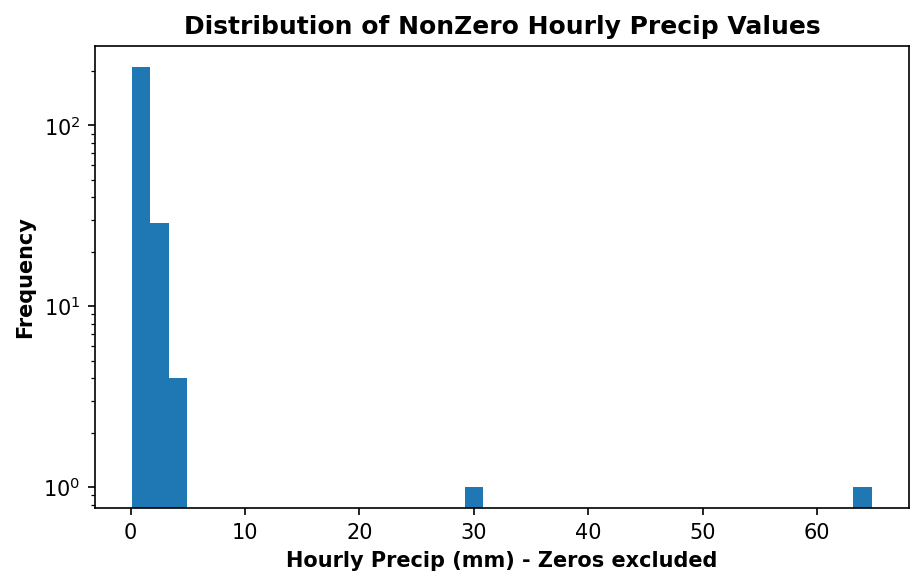

In [136]:


# first lets plot the data - we will plot the values above 0 first
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
nonzero = basin_df_dedup.loc[basin_df_dedup["precip_1h_mm"] > 0, "precip_1h_mm"]
nonzero.plot(kind="hist", bins=40, ax=ax, log=True)
ax.set_xlabel("Hourly Precip (mm) - Zeros excluded", fontweight='bold')
ax.set_ylabel("Frequency", fontweight='bold')
ax.set_title("Distribution of NonZero Hourly Precip Values", fontweight='bold')
plt.show()


> The nonzero-value histogram confirms what the stats already told us - this was a mostly dry day, with almost every real reading sitting under 5mm and only two values (30mm and 65mm) sitting way out on their own. We needed the log scale just to make those two visible at all, on a normal scale they will basically disappear next to everything else.


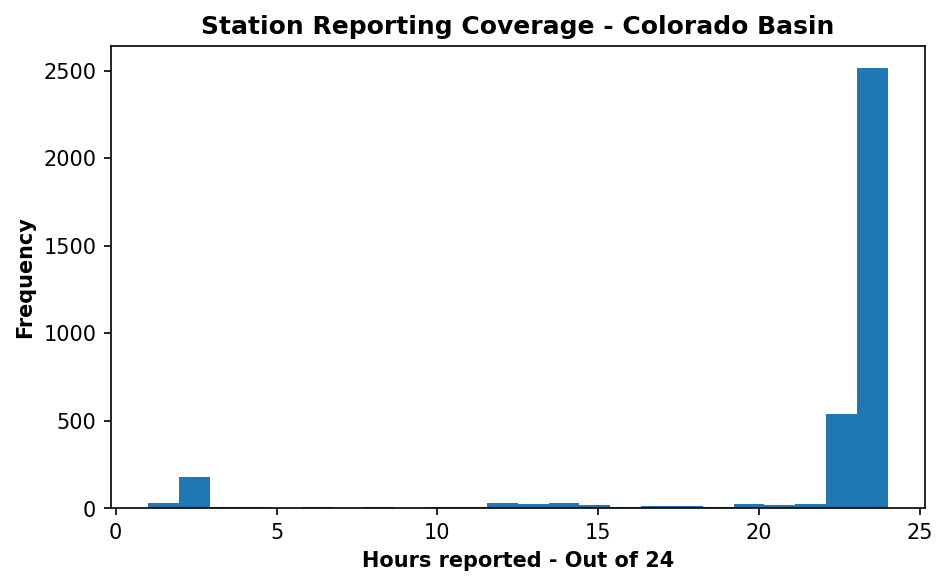

In [139]:

# now lets see the hourly coverage
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
station_counts.plot(kind="hist", bins=24, ax=ax)
ax.set_xlabel("Hours reported - Out of 24", fontweight='bold')
ax.set_ylabel("Frequency", fontweight='bold')
ax.set_title("Station Reporting Coverage - Colorado Basin", fontweight='bold')
plt.show()
             

>Station coverage is mostly a clean story too - the huge majority of stations - 2500 - reported all 24 hours. There is a small but distinct bump around the 2-hour mark, which is worth a second look later - that is a specific cluster of stations dropping out almost immediately rather than randomly losing an hour here or there, and might point to a particular provider or a specific outage rather than noise.

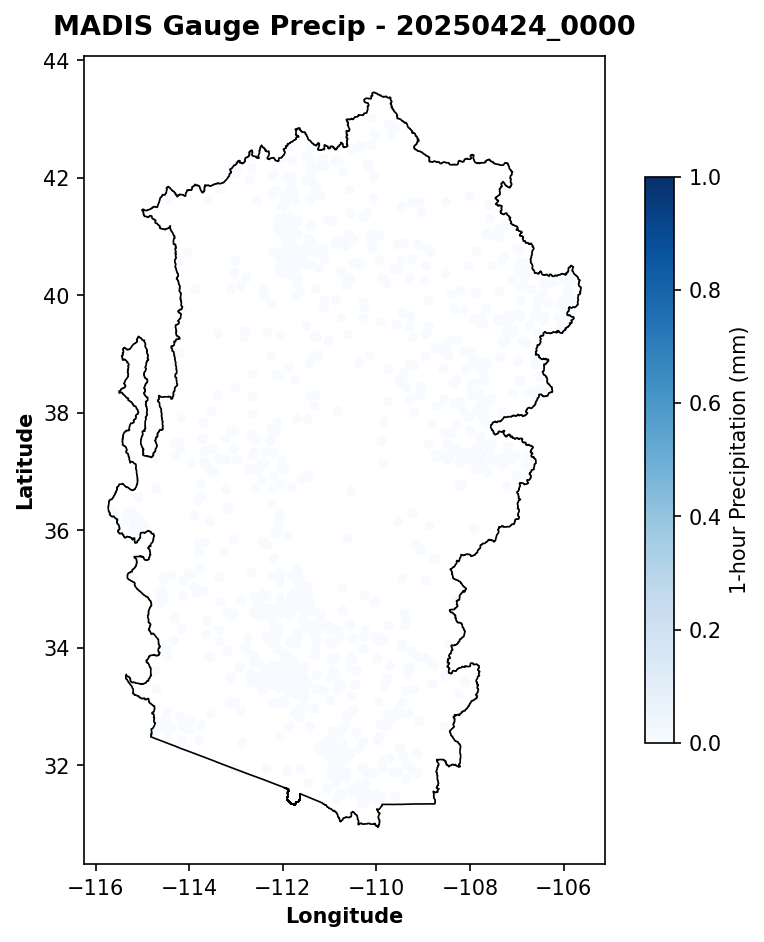

In [148]:

# now lets select a random hour and visualize the data for that random hour in the form of heatmap
random_hour = random.choice(sorted(basin_df_dedup["nominal_time"].unique()))
hourly = basin_df_dedup[(basin_df_dedup["nominal_time"] == random_hour) 
            & basin_df_dedup["precip_1h_mm"].notna()]

vmax = max(hourly["precip_1h_mm"].quantile(0.99), 1.0)  # floor at 1mm so near-dry hours still render sanely

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)
colrd_data.boundary.plot(ax=ax, color="black", linewidth=0.8)
hourly.plot(ax=ax, column="precip_1h_mm", cmap="Blues", markersize=15,
            vmin=0, vmax=vmax, legend=True,
            legend_kwds={"label": "1-hour Precipitation (mm)", "shrink": 0.7})

plt.title(f"MADIS Gauge Precip - {random_hour}", fontweight="bold", fontsize=13, pad=10)
ax.set_xlabel("Longitude", fontweight='bold', fontsize=10)
ax.set_ylabel("Latitude", fontweight='bold', fontsize=10)

plt.show()


>The single-hour map now shows a real, non-fake scale - and confirms what we already knew from the stats: this hour is essentially dry across the whole basin, just faint, near-uniform light dots everywhere. 

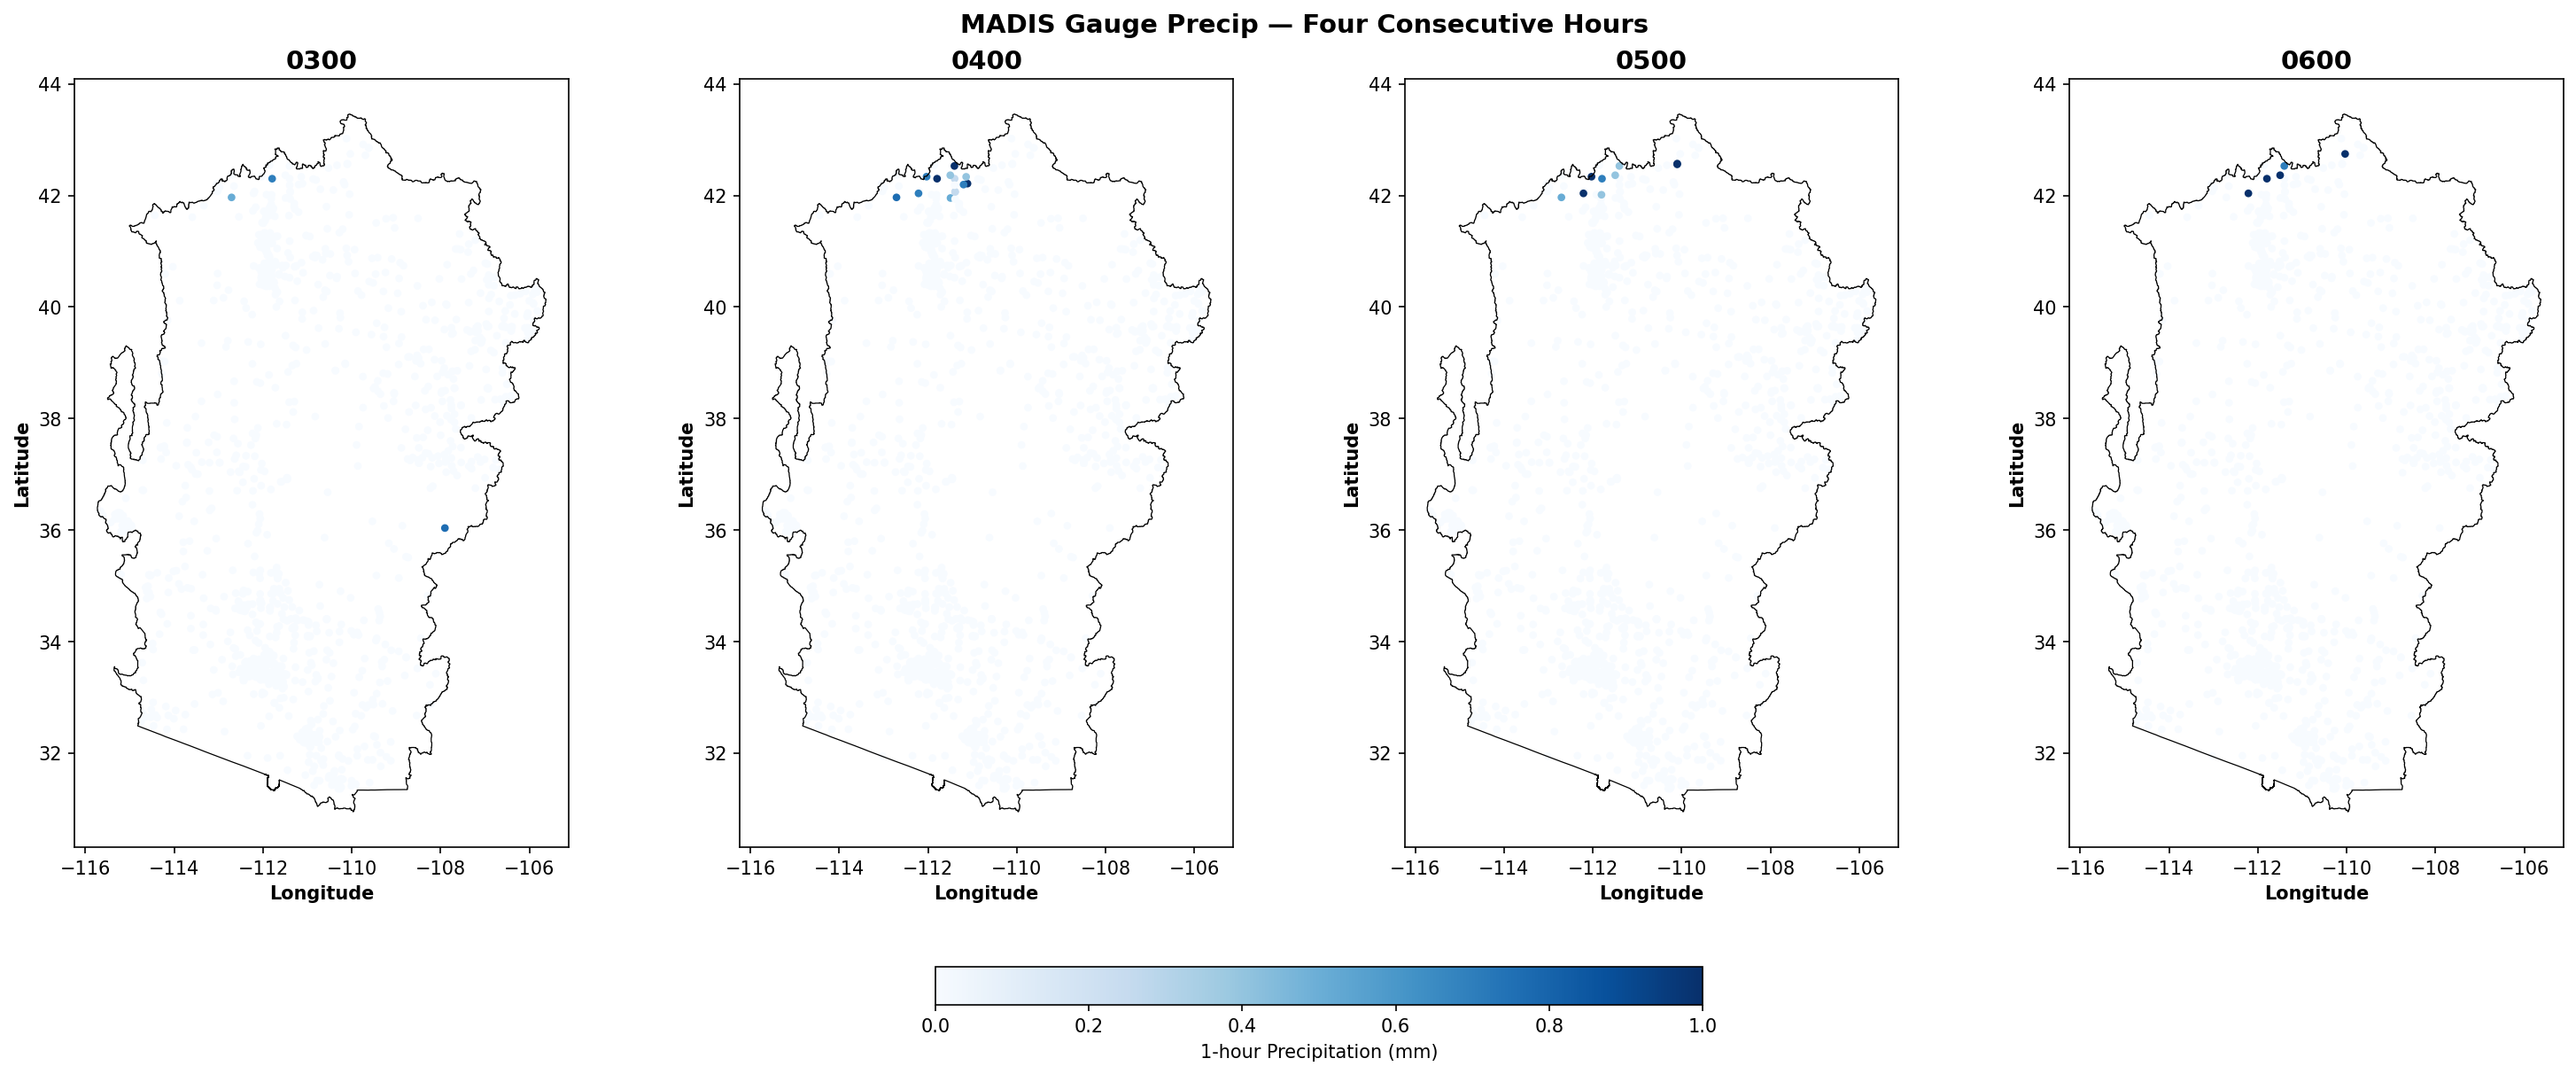

In [150]:

# now lets do the same but this time we will select continuous hours
all_hours = sorted(basin_df_dedup["nominal_time"].unique())
start_idx = random.randint(0, len(all_hours) - 4)
four_hours = all_hours[start_idx : start_idx + 4]

window_vals = basin_df_dedup.loc[basin_df_dedup["nominal_time"].isin(four_hours), "precip_1h_mm"]
common_vmax = max(window_vals.quantile(0.99), 1.0)  # same floor fix

fig, axes = plt.subplots(1, len(four_hours), figsize=(20, 8), dpi=150, constrained_layout=True)
for ax, hr in zip(axes, four_hours):
    colrd_data.boundary.plot(ax=ax, color="black", linewidth=0.6)
    hourly = basin_df_dedup[(basin_df_dedup["nominal_time"] == hr) & basin_df_dedup["precip_1h_mm"].notna()]
    hourly.plot(ax=ax, column="precip_1h_mm", cmap="Blues", markersize=10, vmin=0, vmax=common_vmax, legend=False)
    
    ax.set_title(hr.split("_")[1], fontweight="bold", fontsize=14)
    ax.set_xlabel("Longitude", fontweight='bold', fontsize=10)
    ax.set_ylabel("Latitude", fontweight='bold', fontsize=10)


sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(vmin=0, vmax=common_vmax))
fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08, label="1-hour Precipitation (mm)")
plt.suptitle("MADIS Gauge Precip — Four Consecutive Hours", fontweight="bold", fontsize=14)
plt.show()


>The four-hour panel is where it gets interesting, and this is a nice example of what a real signal looks like compared to the isolated spikes we found earlier. There is a small cluster of stations up in the north that builds from a couple of light dots at 0300, peaks with several darker points at 0400, then gradually fades back down through 0500 and 0600. That buildup-then-decay pattern across neighboring stations and consecutive hours is exactly the shape a real, physically coherent storm cell should have - very different from KBPI's lone spike that appeared and vanished in a single frame with nothing around it.

>One thing worth a quick look later, though: there is a single isolated dot down south (0300) that shows up in that one frame and is completely gone by 0400, with nothing near it. Not flagging it as bad yet, could easily be a short, localized shower, but it has the same alone in time and space shape that made us suspicious of KBPI, so it is worth the same kind of check whenever we get to it.


### **Conclusion**

In this notebook we worked through the MADIS gauge observation product from the ground up — understanding what it is, how to access it, and how to turn a raw request into a clean, analysis-ready table for a single RFC region.

**What we set out to do:** establish MADIS gauge precipitation as the third input for our reliability-aware QPE correction framework, alongside RadarOnly QPE and RAQI. Specifically, get standardized 1-hour gauge accumulations that line up with MRMS `RadarOnly_QPE_01H` for the Colorado Basin.

**What we actually built and learned:**

- **Access method.** We chose MADIS's public web query interface over both the raw-NetCDF route (which would force us to reconstruct provider-specific accumulation conventions ourselves) and the local Fortran "MADIS API" tool (which adds setup complexity without removing the parsing work). The web interface hands back standardized, QC-tagged, single-variable data via a plain HTTP request.

- **Two hourly variables, not one.** `PCP1H` alone silently excludes ASOS-HFM stations, which report only under `PCP1HA`. We combine both into a single hourly value.

- **The data is sparse, in two distinct ways.** Of all theoretically possible station-hours in the basin, ~9% never returned a row at all, and ~65% of the rows that did return carry no usable precip value. Only about a third of the possible station-hour slots give us a real number on a normal day. This is our baseline sense of "how gauge-sparse is gauge-sparse."

- **Duplicates are structural, not errors.** The same physical gauge often reports through multiple pipelines (MesoWest, HADS, CRN) under one station ID. We resolve these with a documented priority order — real value first, avoid the time-uncertain ASOS-HFM pathway, prefer readings closest to the clock hour, then QC rank — and we flag (rather than delete) the cases decided by an arbitrary tie-break.

- **QC is coarser than the scale suggests.** No station in the basin received a `V` or `S` flag on our sample day — only `C`, `Z`, or missing. Our eventual confidence-weighting scheme needs to account for this rather than assume a full spread across QC levels.

- **We flag rather than discard.** Every judgment call — suspected outliers (`outlier_suspect`), time-window uncertainty (`time_window_uncertain`), arbitrary tie-breaks (`tie_break_arbitrary`) — is carried as a column, consistent with the project's reliability-aware philosophy: let the model weight uncertain data rather than throwing it away upstream.

The result is a clean, flagged, one-row-per-station-hour table for a single day and single RFC — the template we'll scale up to the full multi-year dataset next.


### **References**

**[10] NOAA — Meteorological Assimilation Data Ingest System (MADIS) Home**
Official MADIS system overview, describing the collection, standardization, and quality control of surface meteorological observations from many contributing networks.
https://madis.ncep.noaa.gov/

**[11] NOAA MADIS — Meteorological Surface Text/XML Viewer**
The public web query interface used in this notebook to request standardized surface observations (including PCP1H/PCP1HA) by time, geographic area, provider, variable, QC level, and output format.
https://madis-data.ncep.noaa.gov/public/sfcdump.html

**[12] NOAA MADIS — Surface Variables Notes (sfc_notes)**
Official documentation of MADIS surface variables and provider-specific conventions, including the One-Minute ASOS (HFMETAR / PCP1HA) accumulation window running approximately :45 past one hour to :44 past the next.
https://madis.ncep.noaa.gov/sfc_notes.shtml

**[13] NOAA MADIS — One-Minute ASOS Precipitation Inventory**
Provider inventory documenting the One-Minute ASOS precipitation reporting behavior and its non-clock-aligned accumulation window.
https://madis.ncep.noaa.gov/omo_precip.shtml

**[14] NOAA MADIS — Mesonet Precipitation Inventory**
Provider-level inventory of precipitation reporting conventions across contributing mesonets, illustrating why accumulation semantics vary by provider.
https://madis.ncep.noaa.gov/mesonet_precip.shtml

**[15] NOAA MADIS — Recent Changes / Version Notes**
Documents MADIS API changes relevant to this work, including the transition of OMO hourly precipitation from PCP1H to PCP1HA.
https://madis.ncep.noaa.gov/madis_recent.shtml

**[16] NOAA MADIS — METAR Dataset Documentation**
Describes MADIS handling of METAR (ASOS/AWOS) reports and their distinction from the One-Minute ASOS binary feed.
https://madis.ncep.noaa.gov/madis_metar.shtml

**[17] USGS — River Forecast Center Boundaries / NWS RFC Shapefiles**
Source of the official River Forecast Center boundary shapefiles used to spatially filter gauge stations to the Colorado Basin RFC.
https://water.noaa.gov/about/rfc